# 🐶🐱 CNN Final Practical: Cats vs Dogs Classification

### 🚀 The Real Question

Until now, we have learned:
- What convolution is
- How pooling works
- How CNN architectures are built

But one key question remains:

👉 **Can a machine actually look at an image and understand what it is?**

---

### 🧠 Human vs Machine

When you see an image of a dog:
- You recognize **ears, fur, shape, posture**
- Your brain extracts **patterns automatically**

But a machine only sees:
- A grid of numbers (pixels)

---

### 🎯 Our Goal Today

We will build a system that can:

✅ Take an image as input  
✅ Learn patterns using CNN  
✅ Classify it as **Cat 🐱 or Dog 🐶**

---

### 🔥 What Makes This Special?

This is not dummy data anymore.

We are working with:
- Real-world images
- Real noise (lighting, angles, background)
- Real complexity

---

### 🧩 Learning Outcome

By the end of this lecture, you will understand:

1. How images are converted into tensors
2. How CNN learns features from real images
3. How to train a CNN model from scratch
4. Why transfer learning works better
5. How to compare models in real-world scenarios

---

👉 This is your first **end-to-end deep learning pipeline**

# 🔁 Complete Deep Learning Pipeline

We will follow this exact workflow:

### 📌 Step 1: Data Preparation
- Load images from dataset
- Create structured dataframe
- Split into train / validation / test

---

### 📌 Step 2: Preprocessing (OpenCV)
- Resize images
- Convert BGR → RGB
- Normalize pixel values
- Convert to tensors
- Save as `.pt` files

---

### 📌 Step 3: CNN from Scratch
- Build custom CNN
- Train model
- Evaluate performance

---

### 📌 Step 4: Visual Understanding
- Apply convolution filters on real images
- Visualize feature maps
- Understand pooling effect

---

### 📌 Step 5: Transfer Learning (ResNet18)
- Use pretrained model
- Modify final layer
- Train efficiently

---

### 📌 Step 6: Model Comparison
- Accuracy comparison
- Training time comparison
- Generalization ability

---

### 📌 Step 7: Final Prediction
- Test on unseen images
- Interpret model outputs

---

🎯 This pipeline is exactly how real-world computer vision systems are built.

# 🔬 Mathematical View of the Problem

An image can be represented as:

$$
X \in \mathbb{R}^{H \times W \times C}
$$

Where:
- $H$: Height  
- $W$: Width  
- $C = 3$: Channels (RGB)

---

### 🎯 Model Objective

We want to learn a function:

$$
f(X; \theta) \rightarrow \{0,1\}
$$

Where:
- $X$: Input image  
- $\theta$: CNN parameters (filters + weights)  

Output:
- $0 \rightarrow$ Cat  
- $1 \rightarrow$ Dog  

---

### 🧠 What CNN Learns

Instead of manually defining features, CNN learns:

- Edges  
- Textures  
- Shapes  
- Object parts  

---

### 🔁 Learning Process

$$
\text{Prediction} \rightarrow \text{Loss} \rightarrow \text{Backpropagation} \rightarrow \text{Update Weights}
$$

---

👉 This is exactly what we studied in ANN  
👉 Now applied to **images instead of vectors**

# ✅ Concept Check

### Q1. Why can't we directly feed image files (.jpg/.png) into a CNN?

**Answer:**
Because CNN operates on numerical tensors. Images must be converted into arrays of pixel values (tensors) before being processed.

---

### Q2. What is the shape of a color image tensor?

**Answer:**

$$
(H, W, 3)
$$

Height × Width × Channels (RGB)

---

### Q3. What does the CNN actually learn from images?

**Answer:**
It learns hierarchical features such as:
- Edges → Textures → Shapes → Object-level representations

---

### Q4. What is the difference between ANN input and CNN input?

**Answer:**
- ANN: Flat vector input  
- CNN: Structured spatial input (image tensor)

---

### Q5. Why do we need validation and test datasets?

**Answer:**
- Validation: for tuning model and hyperparameters  
- Test: for final unbiased evaluation of model performance

# ⚙️ Environment Setup

Before building our CNN pipeline, we need to:

1. Import required libraries
2. Set up device (CPU vs GPU)
3. Verify if GPU is available

---

### 🧠 Why This Matters?

Deep learning involves:
- Large matrix operations
- Convolutions across images
- Millions of parameters

👉 This is computationally expensive

---

### ⚡ CPU vs GPU

| Feature | CPU | GPU |
|--------|-----|-----|
| Processing | Sequential | Parallel |
| Speed | Slower for DL | Much faster |
| Best for | General tasks | Deep learning |

---

👉 In this lecture, we will use GPU if available

In [1]:
# Basic libraries
import os
import glob
import random
import time

# Data handling
import numpy as np
import pandas as pd

# Image processing
import cv2

# Visualization
import matplotlib.pyplot as plt

# ML utilities
from sklearn.model_selection import train_test_split

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Progress bar
from tqdm import tqdm

# For reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

# 🧠 Device Selection: CPU vs GPU

PyTorch allows us to run computations on:

- CPU (default)
- GPU (if available)

---

### 🔍 How It Works

We define a device:

$$
\text{device} = \text{cuda if available else cpu}
$$

---

### ⚠️ Important Rule

👉 Every tensor and model must be moved to the same device

Otherwise:
- You will get runtime errors

---

### 🧠 Think of it like:

- CPU = normal worker  
- GPU = thousands of workers working in parallel  

---

👉 Let's check what we have available

In [2]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Additional GPU info
if device.type == "cuda":
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("GPU Count:", torch.cuda.device_count())

Using device: cuda
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Count: 1


In [3]:
# Simple benchmark to show speed difference

size = 1000

# CPU computation
start = time.time()
a = torch.randn(size, size)
b = torch.matmul(a, a)
cpu_time = time.time() - start

# GPU computation (if available)
if device.type == "cuda":
    start = time.time()
    a = torch.randn(size, size).to(device)
    b = torch.matmul(a, a)
    torch.cuda.synchronize()
    gpu_time = time.time() - start
    
    print(f"CPU Time: {cpu_time:.4f} sec")
    print(f"GPU Time: {gpu_time:.4f} sec")
else:
    print(f"CPU Time: {cpu_time:.4f} sec")
    print("GPU not available")

CPU Time: 0.0913 sec
GPU Time: 2.1450 sec


In [4]:
import time
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

size = 4000
repeats = 20

# CPU benchmark
a_cpu = torch.randn(size, size)
b_cpu = torch.randn(size, size)

start = time.time()
for _ in range(repeats):
    c_cpu = torch.matmul(a_cpu, b_cpu)
cpu_time = time.time() - start

print(f"CPU total time over {repeats} runs: {cpu_time:.4f} sec")
print(f"CPU average per run: {cpu_time/repeats:.4f} sec")

# GPU benchmark
if device.type == "cuda":
    a_gpu = torch.randn(size, size, device=device)
    b_gpu = torch.randn(size, size, device=device)

    # Warm-up
    for _ in range(5):
        _ = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()

    start = time.time()
    for _ in range(repeats):
        c_gpu = torch.matmul(a_gpu, b_gpu)
    torch.cuda.synchronize()
    gpu_time = time.time() - start

    print(f"GPU total time over {repeats} runs: {gpu_time:.4f} sec")
    print(f"GPU average per run: {gpu_time/repeats:.4f} sec")
else:
    print("GPU not available")

Using device: cuda
CPU total time over 20 runs: 6.3280 sec
CPU average per run: 0.3164 sec
GPU total time over 20 runs: 0.4540 sec
GPU average per run: 0.0227 sec


# 📊 What Did We Observe?

- Matrix multiplication on GPU is significantly faster
- Deep learning involves **thousands of such operations**

---

### 🎯 Key Insight

👉 Training a CNN without GPU can be:

- Very slow  
- Sometimes impractical  

---

### 🧠 Practical Reality

In real-world ML workflows:

- GPU = standard for training  
- CPU = often used for inference  

---

👉 From now on, we will ensure:
- Data → device  
- Model → device  

# ✅ Concept Check

### Q1. Why is GPU preferred for deep learning?

**Answer:**
Because GPU performs parallel computation, which is ideal for matrix operations and convolutions used in deep learning.

---

### Q2. What happens if model is on GPU but data is on CPU?

**Answer:**
It will throw a runtime error due to device mismatch.

---

### Q3. What does `torch.cuda.is_available()` check?

**Answer:**
It checks whether a CUDA-enabled GPU is available for computation.

---

### Q4. Why do we use `.to(device)`?

**Answer:**
To move tensors and models to the same computation device (CPU or GPU).

---

### Q5. Is GPU always required?

**Answer:**
No, but it significantly speeds up training, especially for large datasets and deep models.

# 📂 Dataset Understanding

We are using the **Dogs vs Cats dataset** from Kaggle.

---

### 📦 Dataset Structure

Typically, the dataset contains images like:

- `cat.0.jpg`
- `dog.1234.jpg`

---

### 🧠 Key Observations

- Images are stored as **files**
- Labels are embedded in **file names**
- No structured format (like CSV)

---

### 🎯 Our Task

We will convert this **unstructured data** into:

👉 A structured **DataFrame**

With columns:
- filepath
- label (cat/dog)
- numeric label (0/1)

---

### 🚨 Why This Step is Important?

Machine Learning pipelines require:
- Structured data
- Clear mapping between input and output

---

👉 Let's start by loading all image paths

In [5]:
# Set dataset path (UPDATE THIS PATH)
dataset_path = "CNN_Demo_Project_1/Training Images"  # e.g., "data/train"

# Get all image file paths
image_paths = glob.glob(os.path.join(dataset_path, "*.jpg"))

print("Total images found:", len(image_paths))
print("Sample paths:", image_paths[:5])

Total images found: 25000
Sample paths: ['CNN_Demo_Project_1/Training Images\\cat.0.jpg', 'CNN_Demo_Project_1/Training Images\\cat.1.jpg', 'CNN_Demo_Project_1/Training Images\\cat.10.jpg', 'CNN_Demo_Project_1/Training Images\\cat.100.jpg', 'CNN_Demo_Project_1/Training Images\\cat.1000.jpg']


# 🏷️ Extracting Labels from File Names

Each image file is named like:

- cat.0.jpg → Cat  
- dog.123.jpg → Dog  

---

### 🧠 Logic

We extract label using:

$$
\text{label} = \text{filename.split(".")[0]}
$$

---

### 🎯 Encoding Labels

We convert:
- Cat → 0  
- Dog → 1  

---

👉 This is called **label encoding**

In [6]:
data = []

for path in image_paths:
    filename = os.path.basename(path)
    label_text = filename.split(".")[0]
    
    label = 0 if label_text == "cat" else 1
    
    data.append([path, label_text, label])

# Create DataFrame
df = pd.DataFrame(data, columns=["filepath", "label_text", "label"])

print(df.head())
print("\nClass distribution:\n", df["label_text"].value_counts())

                                          filepath label_text  label
0     CNN_Demo_Project_1/Training Images\cat.0.jpg        cat      0
1     CNN_Demo_Project_1/Training Images\cat.1.jpg        cat      0
2    CNN_Demo_Project_1/Training Images\cat.10.jpg        cat      0
3   CNN_Demo_Project_1/Training Images\cat.100.jpg        cat      0
4  CNN_Demo_Project_1/Training Images\cat.1000.jpg        cat      0

Class distribution:
 label_text
cat    12500
dog    12500
Name: count, dtype: int64


# 📊 What Did We Just Do?

We converted:

👉 Unstructured image files  
➡️ Structured tabular data

---

### 🧠 Why This Matters

Now we can:
- Shuffle data
- Split into train/validation/test
- Apply preprocessing systematically

---

### 🎯 This is exactly how real ML pipelines start

Raw data → Structured format → Processing → Model

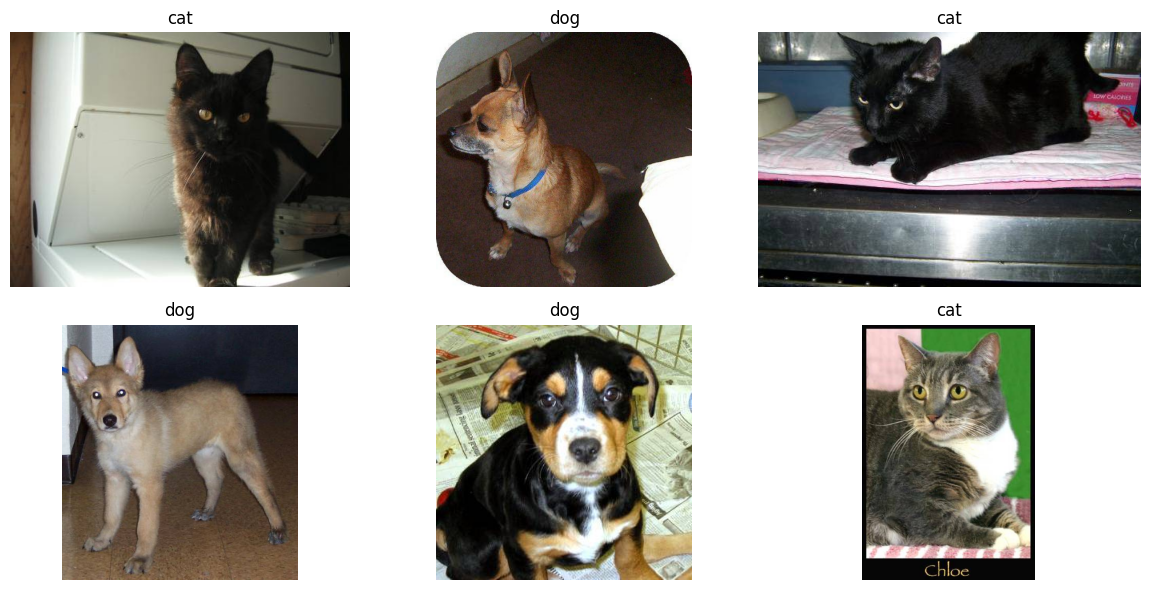

In [7]:
# Function to display images
def show_images(df, n=6):
    plt.figure(figsize=(12, 6))
    
    sample_df = df.sample(n)
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(2, 3, i+1)
        plt.imshow(img)
        plt.title(row["label_text"])
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

# Display images
show_images(df)

# 🔢 Image = Numbers

An image is not “seen” by the machine as a picture.

It is a **matrix of numbers**.

---

### 🎯 Example Representation

Each pixel has values:

$$
\text{Pixel} = (R, G, B)
$$

Each value ranges from:

$$
0 \rightarrow 255
$$

---

### 🧠 Full Image

An image becomes:

$$
X \in \mathbb{R}^{H \times W \times 3}
$$

---

👉 Let’s actually inspect this numerically

In [8]:
# Take one sample image
sample_path = df.iloc[0]["filepath"]

img = cv2.imread(sample_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

print("Image shape:", img_rgb.shape)
print("Data type:", img_rgb.dtype)

# Show pixel values of a small patch
print("\nSample pixel values (top-left 3x3 region):\n")
print(img_rgb[:3, :3, :])

Image shape: (374, 500, 3)
Data type: uint8

Sample pixel values (top-left 3x3 region):

[[[203 164  87]
  [203 164  87]
  [204 165  88]]

 [[203 164  87]
  [203 164  87]
  [204 165  88]]

 [[203 164  87]
  [203 164  87]
  [204 165  88]]]


# 🧠 What Did We Observe?

### 📌 Image Shape

$$
(H, W, 3)
$$

- Height
- Width
- RGB channels

---

### 📌 Pixel Values

Each pixel contains:

$$
(R, G, B)
$$

---

### 🎯 Key Insight

👉 CNN does not see:
- ears
- tails
- faces  

👉 It only sees:
- numbers arranged in a grid  

---

### 🔥 Powerful Realization

> “Meaning is not given to the model — it is learned from patterns in numbers.”

# ✅ Concept Check

### Q1. How do we extract labels from image files?

**Answer:**
From the filename using string operations like `split(".")`.

---

### Q2. Why do we convert data into a DataFrame?

**Answer:**
To structure data for easier manipulation, splitting, and preprocessing.

---

### Q3. What is the shape of an RGB image?

**Answer:**

$$
(H, W, 3)
$$

---

### Q4. What does each pixel represent?

**Answer:**
A tuple of intensity values: (R, G, B)

---

### Q5. Does CNN understand objects directly?

**Answer:**
No, it learns patterns from pixel values and builds hierarchical representations.

# 🎯 Why Do We Subset and Split Data?

We have ~25,000 images, but:

---

### 🚨 Problem

- Training on full dataset = slow  
- Not suitable for classroom demonstration  

---

### 🎯 Solution

We create a **controlled subset**:

- Faster training  
- Easier experimentation  
- Reproducible results  

---

### 📊 Our Strategy

We will use:

- Train set → model learns  
- Validation set → hyperparameter tuning  
- Test set → final evaluation  

---

### 🧠 Key Principle

$$
\text{Train} \neq \text{Validation} \neq \text{Test}
$$

---

👉 This separation prevents **overfitting and bias**

In [9]:
# Separate cat and dog images
cat_df = df[df["label_text"] == "cat"]
dog_df = df[df["label_text"] == "dog"]

print("Total Cats:", len(cat_df))
print("Total Dogs:", len(dog_df))

Total Cats: 12500
Total Dogs: 12500


# ⚖️ Balanced Dataset

If one class dominates:

👉 Model becomes biased

---

### 🎯 Goal

Equal representation:

$$
\text{Cats} = \text{Dogs}
$$

---

### 🧠 Why?

- Prevents biased learning  
- Improves generalization  
- Makes evaluation meaningful  

---

👉 We will sample equal number of images from both classes

In [10]:
# Define sample size per class
sample_size = 6000  # you can change to 4000 or 5000 if needed

cat_sample = cat_df.sample(n=sample_size, random_state=42)
dog_sample = dog_df.sample(n=sample_size, random_state=42)

# Combine
df_sampled = pd.concat([cat_sample, dog_sample]).reset_index(drop=True)

# Shuffle
df_sampled = df_sampled.sample(frac=1, random_state=42).reset_index(drop=True)

print("Sampled dataset size:", len(df_sampled))
print(df_sampled["label_text"].value_counts())

Sampled dataset size: 12000
label_text
cat    6000
dog    6000
Name: count, dtype: int64


# 🔀 Train / Validation / Test Split

We divide dataset into:

---

### 📊 Typical Split

- Train → 70%
- Validation → 15%
- Test → 15%

---

### 🎯 Why?

- Train → learn patterns  
- Validation → tune model  
- Test → evaluate final performance  

---

### 🧠 Important Rule

👉 Test data must NEVER be used during training

---

### Mathematical Representation

$$
D = D_{train} \cup D_{val} \cup D_{test}
$$

$$
D_{train} \cap D_{val} \cap D_{test} = \emptyset
$$

In [11]:
# First split: Train vs Temp (val + test)
train_df, temp_df = train_test_split(
    df_sampled,
    test_size=0.3,
    stratify=df_sampled["label"],
    random_state=42
)

# Second split: Validation vs Test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 8400
Validation size: 1800
Test size: 1800


# 📊 Checking Class Distribution

After splitting, we must ensure:

$$
\text{Distribution is balanced across all sets}
$$

---

### 🎯 Why?

- Prevent skewed evaluation  
- Ensure fairness  
- Maintain consistency  

---

👉 Let's verify distribution

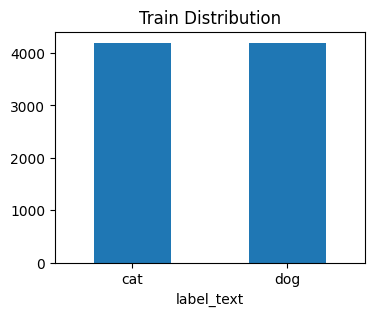

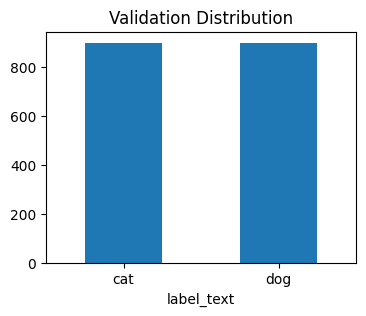

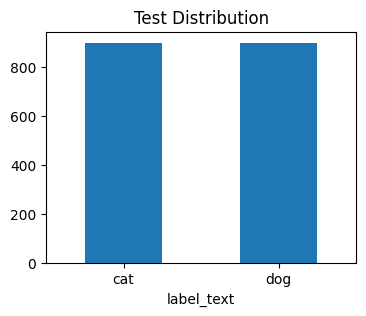

In [12]:
def plot_distribution(df, title):
    counts = df["label_text"].value_counts()
    
    plt.figure(figsize=(4,3))
    counts.plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=0)
    plt.show()

plot_distribution(train_df, "Train Distribution")
plot_distribution(val_df, "Validation Distribution")
plot_distribution(test_df, "Test Distribution")

# 🧠 What Did We Achieve?

### ✅ Controlled Dataset

- Balanced classes  
- Reduced size for faster training  

---

### ✅ Proper Splitting

- Train → learning  
- Validation → tuning  
- Test → final evaluation  

---

### 🎯 Key Insight

👉 Good data preparation is as important as model design  

---

### 🔥 Industry Insight

Most ML failures happen due to:
- Poor data splitting  
- Data leakage  
- Imbalanced datasets  

---

👉 We have avoided these issues here

# ✅ Concept Check

### Q1. Why do we create a subset of the dataset?

**Answer:**
To reduce training time and make experimentation faster and manageable.

---

### Q2. What happens if dataset is imbalanced?

**Answer:**
Model becomes biased towards the dominant class and performs poorly on minority class.

---

### Q3. Why do we use stratified splitting?

**Answer:**
To maintain class distribution across train, validation, and test sets.

---

### Q4. Can we use test data during training?

**Answer:**
No, it leads to biased evaluation and overfitting.

---

### Q5. What is the purpose of validation data?

**Answer:**
To tune hyperparameters and monitor model performance during training.

# 🧹 Why Do We Preprocess Images?

Raw images cannot be directly fed into CNN.

---

### 🚨 Problems with Raw Images

- Different sizes  
- Different lighting conditions  
- Different pixel ranges  

---

### 🎯 Preprocessing Goals

We want to:

1. Resize images → fixed dimensions  
2. Convert BGR → RGB  
3. Normalize pixel values  
4. Convert to tensor format  

---

### 🧠 Mathematical View

Pixel values range:

$$
0 \rightarrow 255
$$

We normalize to:

$$
0 \rightarrow 1
$$

---

### 🎯 Why Normalize?

- Faster convergence  
- Stable gradients  
- Better training  

---

👉 Let’s build the preprocessing pipeline

In [13]:
IMG_SIZE = 128  # you can change to 224 for ResNet

def preprocess_image(path):
    # Read image
    img = cv2.imread(path)
    
    # Resize
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    
    # Convert BGR → RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Normalize
    img = img / 255.0
    
    return img

# 👁️ Visualizing Preprocessing

We will compare:

- Original image  
- Resized image  
- Normalized values  

---

👉 This helps us understand what changes before training

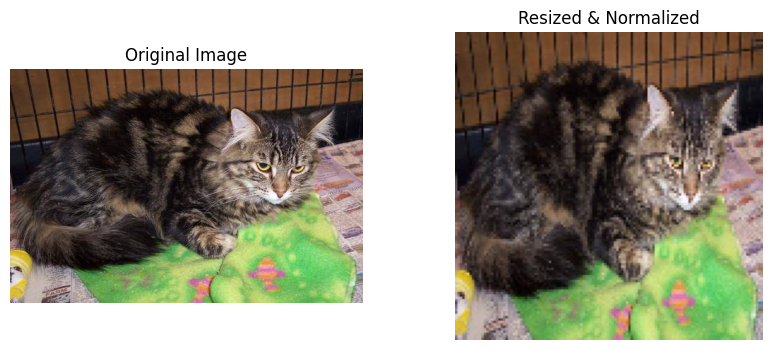

Original shape: (333, 500, 3)
Processed shape: (128, 128, 3)
Pixel range after normalization: 0.0 to 1.0


In [14]:
sample_path = train_df.iloc[0]["filepath"]

# Original
img_orig = cv2.imread(sample_path)
img_orig_rgb = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)

# Processed
img_processed = preprocess_image(sample_path)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img_orig_rgb)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_processed)
plt.title("Resized & Normalized")
plt.axis("off")

plt.show()

print("Original shape:", img_orig_rgb.shape)
print("Processed shape:", img_processed.shape)
print("Pixel range after normalization:", 
      img_processed.min(), "to", img_processed.max())

# 🔄 From Image to Tensor

OpenCV gives image in:

$$
(H, W, C)
$$

But PyTorch expects:

$$
(C, H, W)
$$

---

### 🎯 Why?

Because convolution operates across channels first.

---

👉 We need to rearrange dimensions

In [15]:
def image_to_tensor(img):
    # Convert to numpy array (already is)
    
    # Change shape: (H, W, C) → (C, H, W)
    img = np.transpose(img, (2, 0, 1))
    
    # Convert to torch tensor
    tensor = torch.tensor(img, dtype=torch.float32)
    
    return tensor

# 🔁 Full Preprocessing Pipeline

For each image:

$$
\text{Image} \rightarrow \text{Resize} \rightarrow \text{Normalize} \rightarrow \text{Tensor}
$$

---

### 🎯 Output

Each sample becomes:

$$
X \in \mathbb{R}^{3 \times H \times W}
$$

---

👉 Now we apply this to the entire dataset

In [16]:
def process_dataframe(df):
    images = []
    labels = []
    
    for _, row in tqdm(df.iterrows(), total=len(df)):
        img = preprocess_image(row["filepath"])
        tensor = image_to_tensor(img)
        
        images.append(tensor)
        labels.append(row["label"])
    
    X = torch.stack(images)
    y = torch.tensor(labels)
    
    return X, y

# Process datasets
X_train, y_train = process_dataframe(train_df)
X_val, y_val = process_dataframe(val_df)
X_test, y_test = process_dataframe(test_df)

print("Train tensor shape:", X_train.shape)
print("Validation tensor shape:", X_val.shape)
print("Test tensor shape:", X_test.shape)

100%|█████████████████████████████████████████████████████████████████████████████| 1800/1800 [00:12<00:00, 145.29it/s]


Train tensor shape: torch.Size([8400, 3, 128, 128])
Validation tensor shape: torch.Size([1800, 3, 128, 128])
Test tensor shape: torch.Size([1800, 3, 128, 128])


# 💾 Saving Processed Data

Processing images repeatedly is slow.

---

### 🎯 Solution

Save processed tensors as `.pt` files

---

### Benefits:

- Faster loading  
- Reproducibility  
- Efficient pipeline  

---

👉 Let’s save tensors

In [17]:
torch.save(X_train, "X_train.pt")
torch.save(y_train, "y_train.pt")

torch.save(X_val, "X_val.pt")
torch.save(y_val, "y_val.pt")

torch.save(X_test, "X_test.pt")
torch.save(y_test, "y_test.pt")

print("Data saved successfully!")

Data saved successfully!


# 🔄 Reloading Saved Data

Instead of reprocessing every time:

👉 We can directly load `.pt` files

---

This is useful for:
- Fast experimentation  
- Classroom demonstration  

In [18]:
X_train = torch.load("X_train.pt")
y_train = torch.load("y_train.pt")

X_val = torch.load("X_val.pt")
y_val = torch.load("y_val.pt")

X_test = torch.load("X_test.pt")
y_test = torch.load("y_test.pt")

print("Data loaded successfully!")

Data loaded successfully!


# 🧠 What Did We Achieve?

### ✅ Converted Images → Tensors

$$
(H, W, C) \rightarrow (C, H, W)
$$

---

### ✅ Normalized Pixel Values

$$
0 \rightarrow 255 \Rightarrow 0 \rightarrow 1
$$

---

### ✅ Created Model-Ready Dataset

- Fast loading  
- Structured tensors  
- Ready for training  

---

### 🎯 Key Insight

👉 Data preprocessing directly impacts model performance  

---

### 🔥 Industry Insight

Most performance gains come from:
- Better data preprocessing  
- Not just better models  

# ✅ Concept Check

### Q1. Why do we resize images?

**Answer:**
To ensure all inputs have the same dimensions for batch processing.

---

### Q2. Why convert BGR to RGB?

**Answer:**
OpenCV loads images in BGR format, but most frameworks expect RGB.

---

### Q3. Why normalize pixel values?

**Answer:**
To stabilize training and improve convergence.

---

### Q4. Why convert (H, W, C) → (C, H, W)?

**Answer:**
PyTorch expects channel-first format for convolution operations.

---

### Q5. Why save data as `.pt` files?

**Answer:**
To avoid repeated preprocessing and speed up workflow.

# 🚀 Beyond Basic Preprocessing (Advanced Perspective)

So far, we used a simple pipeline:

$$
\text{Resize} \rightarrow \text{Normalize} \rightarrow \text{Tensor}
$$

---

### ⚠️ Limitation of Current Approach

- Fixed resizing may distort aspect ratio  
- No data augmentation → model may overfit  
- Normalization is generic (0–1 scaling only)  

---

## 🔬 1. Data Augmentation (Very Important)

Instead of increasing dataset size manually, we can **create variations**:

- Horizontal Flip  
- Rotation  
- Zoom  
- Brightness change  

---

### 🎯 Why?

$$
\text{More Data Diversity} \Rightarrow \text{Better Generalization}
$$

---

## 🔬 2. Mean-Std Normalization

Instead of:

$$
x \rightarrow \frac{x}{255}
$$

We use:

$$
x' = \frac{x - \mu}{\sigma}
$$

---

### 🎯 Why?

- Centers data  
- Improves gradient flow  
- Standard practice in pretrained models  

---

## 🔬 3. On-the-Fly Preprocessing

Instead of saving `.pt`:

👉 Use custom Dataset class:

- Load image when needed  
- Apply transformations dynamically  

---

### 🎯 Benefit

- Saves memory  
- Enables real-time augmentation  

---

## 🔬 4. Resolution Trade-off

- Smaller images → faster training  
- Larger images → better feature capture  

---

### 🎯 Tradeoff

$$
\text{Speed} \leftrightarrow \text{Accuracy}
$$

---

## 🧠 Key Takeaway

> “In real-world ML, preprocessing is not fixed — it is a design decision.”

---

👉 What we built today is a **baseline pipeline**

👉 What industry uses is a **refined + optimized pipeline**

# 📦 Why Do We Use DataLoader?

We now have:

- Image tensors  
- Labels  

---

### 🚨 Problem

Feeding entire dataset at once:

- Memory inefficient  
- Computationally expensive  
- Not scalable  

---

### 🎯 Solution: Mini-Batches

Instead of full dataset:

$$
\text{Dataset} \rightarrow \text{Batches}
$$

---

### 🧠 Example

If dataset has 8000 images:

- Batch size = 32  
- Total batches:

$$
\frac{8000}{32} = 250
$$

---

### 🎯 Benefits

- Faster training  
- Stable gradient updates  
- Better generalization  

---

👉 PyTorch provides **DataLoader** for this

In [19]:
# Create TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

print("Train dataset size:", len(train_dataset))

Train dataset size: 8400


# 🔄 DataLoader: How It Works

DataLoader wraps dataset and provides:

- Batching  
- Shuffling  
- Iteration  

---

### 🎯 Key Parameters

- `batch_size` → number of samples per batch  
- `shuffle=True` → randomizes data  
- `num_workers` → parallel loading  

---

### 🧠 Training Rule

- Train → shuffle = True  
- Validation/Test → shuffle = False  

---

👉 Let’s create DataLoaders

In [20]:
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of train batches:", len(train_loader))

Number of train batches: 263


# 👁️ What Does the Model Actually See?

The model never sees full dataset.

---

### It sees:

$$
\text{Batch} \in \mathbb{R}^{B \times C \times H \times W}
$$

Where:

- $B$ → Batch size  
- $C$ → Channels  
- $H, W$ → Height, Width  

---

### 🎯 Example

If:
- Batch size = 32  
- Image size = 128 × 128  

Then:

$$
(32, 3, 128, 128)
$$

---

👉 Let’s inspect one batch

In [21]:
# Get one batch
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)
print("Labels shape:", labels.shape)

Batch shape: torch.Size([32, 3, 128, 128])
Labels shape: torch.Size([32])


# ⚡ Moving Data to Device

We must ensure:

$$
\text{Data and Model on same device}
$$

---

### 🎯 Why?

- Avoid runtime errors  
- Enable GPU acceleration  

---

👉 Move batch to device

In [22]:
images = images.to(device)
labels = labels.to(device)

print("Device of images:", images.device)

Device of images: cuda:0


# 🖼️ Visualizing Batch Samples

Before training, we must verify:

- Images are correct  
- Labels are correct  
- No preprocessing issues  

---

👉 Let’s visualize a batch

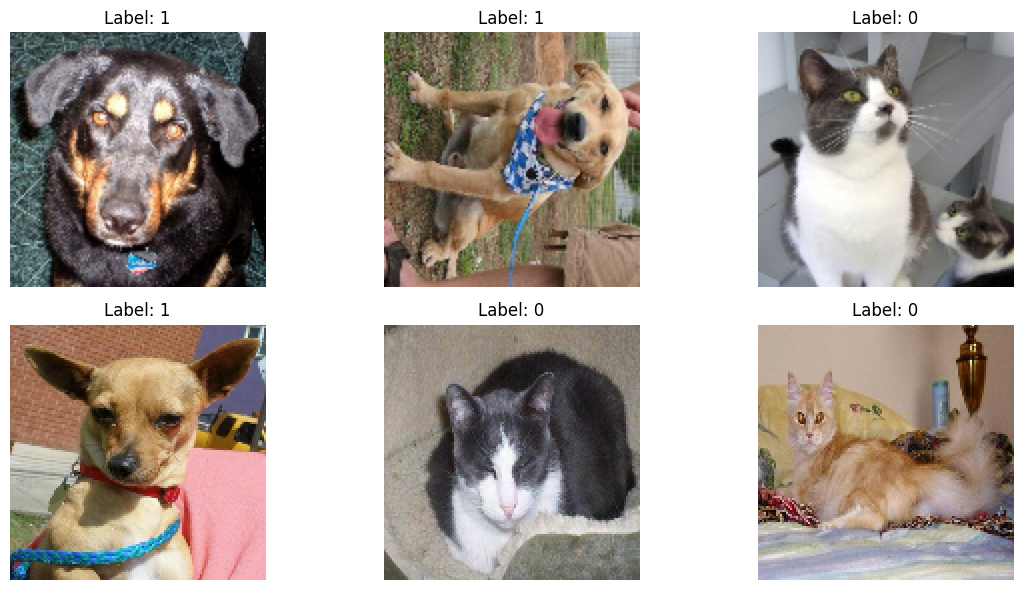

In [23]:
def show_batch(images, labels, n=6):
    images = images.cpu()  # move back to CPU for visualization
    
    plt.figure(figsize=(12,6))
    
    for i in range(n):
        img = images[i].permute(1, 2, 0)  # (C,H,W) → (H,W,C)
        
        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    
    plt.tight_layout()
    plt.show()

show_batch(images, labels)

# 🧠 What Did We Achieve?

### ✅ Efficient Data Pipeline

- Data is batched  
- Data is shuffled  
- Ready for training  

---

### ✅ Model Input Format

$$
(B, C, H, W)
$$

---

### 🎯 Key Insight

👉 CNN does not see single image  

👉 It learns from **batches of images**

---

### 🔥 Deep Insight

Batching introduces:

- Noise in gradients  
- Better generalization  
- Faster convergence  

---

👉 This is why mini-batch gradient descent is used

# ✅ Concept Check

### Q1. Why do we use batches instead of full dataset?

**Answer:**
To reduce memory usage and enable efficient gradient updates.

---

### Q2. What does DataLoader do?

**Answer:**
It provides batching, shuffling, and iteration over dataset.

---

### Q3. What is the shape of a batch?

**Answer:**

$$
(B, C, H, W)
$$

---

### Q4. Why do we shuffle training data?

**Answer:**
To avoid learning order-specific patterns and improve generalization.

---

### Q5. Why must data and model be on same device?

**Answer:**
To avoid runtime errors and enable proper computation.

# 👁️ Understanding Convolution on Real Images

So far, we learned convolution using:

- Dummy matrices  
- Simple filters  

---

### 🚨 But real question is:

👉 What happens when we apply convolution on **real images**?

---

### 🧠 Key Idea

CNN does not see objects.

It detects:

- Edges  
- Patterns  
- Textures  

---

### 🎯 Goal of This Section

We will:

1. Apply filters on real image  
2. Visualize feature maps  
3. Understand pooling effect  

---

👉 This is how CNN "sees" images

(np.float64(-0.5), np.float64(499.5), np.float64(332.5), np.float64(-0.5))

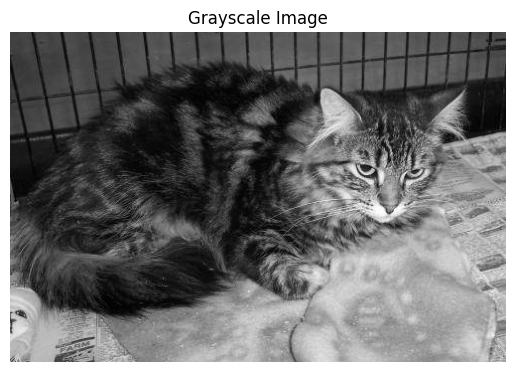

In [24]:
# Select one sample image
sample_path = train_df.iloc[0]["filepath"]

img = cv2.imread(sample_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale for simplicity
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")

# 🔍 Convolution Operation

A filter (kernel) slides over the image:

$$
\text{Output} = \text{Image} * \text{Kernel}
$$

---

### 🎯 What it does?

- Highlights specific patterns  
- Suppresses irrelevant information  

---

### 🧠 Types of Filters

- Edge detection  
- Sharpening  
- Blurring  

---

👉 Let’s apply some filters

# Edge detection filter
edge_filter = np.array([
    [-1, -1, -1],
    [-1,  8, -1],
    [-1, -1, -1]
])

# Sharpen filter
sharpen_filter = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

# Blur filter
blur_filter = np.ones((3,3)) / 9

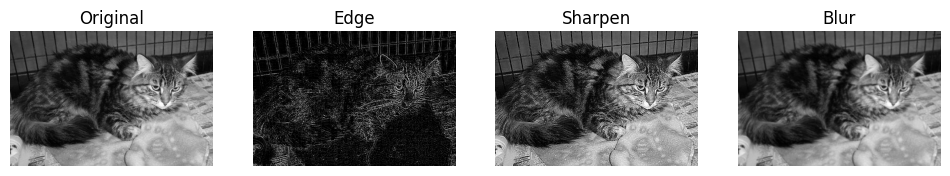

In [26]:
# Apply filters
edge_img = cv2.filter2D(gray, -1, edge_filter)
sharpen_img = cv2.filter2D(gray, -1, sharpen_filter)
blur_img = cv2.filter2D(gray, -1, blur_filter)

# Plot results
plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(edge_img, cmap='gray')
plt.title("Edge")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(sharpen_img, cmap='gray')
plt.title("Sharpen")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(blur_img, cmap='gray')
plt.title("Blur")
plt.axis("off")

plt.show()

# 🧠 What Did We Observe?

### 📌 Edge Filter

- Highlights boundaries  
- Detects shape  

---

### 📌 Sharpen Filter

- Enhances details  
- Increases contrast  

---

### 📌 Blur Filter

- Smooths image  
- Removes noise  

---

### 🎯 Key Insight

👉 Each filter extracts a **different feature**

---

### 🔥 CNN Connection

Instead of manually defining filters:

👉 CNN **learns these filters automatically**

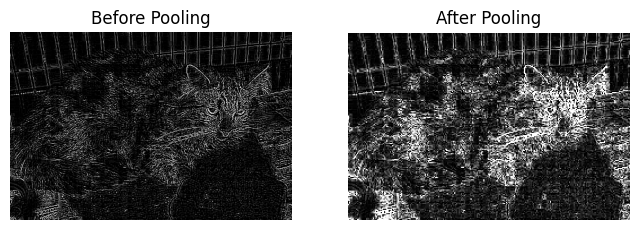

Original shape: (333, 500)
Pooled shape: (166, 250)


In [28]:
# Simple max pooling function
def max_pooling(img, size=2):
    h, w = img.shape
    
    # Ensure dimensions divisible by size
    h_new = h // size
    w_new = w // size
    
    pooled = np.zeros((h_new, w_new))
    
    for i in range(h_new):
        for j in range(w_new):
            pooled[i, j] = np.max(
                img[i*size:(i+1)*size, j*size:(j+1)*size]
            )
    
    return pooled

pooled_img = max_pooling(edge_img, size=2)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(edge_img, cmap='gray')
plt.title("Before Pooling")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(pooled_img, cmap='gray')
plt.title("After Pooling")
plt.axis("off")

plt.show()

print("Original shape:", edge_img.shape)
print("Pooled shape:", pooled_img.shape)

# 🧩 Pooling Operation

Pooling reduces spatial dimensions:

$$
(H, W) \rightarrow \left(\frac{H}{2}, \frac{W}{2}\right)
$$

---

### 🎯 Why Pooling?

- Reduces computation  
- Retains important features  
- Adds translation invariance  

---

### 🧠 Key Insight

👉 We keep **important signals**  
👉 Remove **redundant information**

In [29]:
# Optional preview (after model training later)
# Placeholder for later use

print("Feature map visualization will be added after CNN training")

Feature map visualization will be added after CNN training


# 🔥 What CNN Actually Learns

Layer-wise understanding:

---

### 🧠 Early Layers

- Edges  
- Corners  
- Basic textures  

---

### 🧠 Middle Layers

- Patterns  
- Fur texture  
- Shapes  

---

### 🧠 Deep Layers

- Face structure  
- Object identity  

---

### 🎯 Key Takeaway

$$
\text{Simple Features} \rightarrow \text{Complex Features}
$$

---

👉 This is called **hierarchical feature learning**

# ✅ Concept Check

### Q1. What does convolution do?

**Answer:**
It extracts patterns such as edges and textures from images.

---

### Q2. Why do we use multiple filters?

**Answer:**
Each filter captures a different feature of the image.

---

### Q3. What does pooling do?

**Answer:**
It reduces spatial dimensions while retaining important features.

---

### Q4. Why convert to grayscale here?

**Answer:**
To simplify visualization of filter effects.

---

### Q5. Does CNN use fixed filters?

**Answer:**
No, CNN learns filters automatically during training.

# 🏗️ Building Our Own CNN

So far, we have:

- Prepared dataset  
- Understood convolution  
- Visualized feature extraction  

---

### 🚨 Question

👉 Can we build a CNN from scratch?

---

### 🎯 Goal

We will build a **custom CNN model** for:

- Binary classification (Cat vs Dog)

---

### 🧠 Key Components

A CNN consists of:

1. Convolution Layers  
2. Activation Functions (ReLU)  
3. Pooling Layers  
4. Fully Connected Layers  
5. Output Layer  

---

👉 Let’s construct this step by step

# 🧩 CNN Architecture Overview

Our model will follow:

---

### 🔷 Block 1
Conv → ReLU → MaxPool  

---

### 🔷 Block 2
Conv → ReLU → MaxPool  

---

### 🔷 Block 3
Conv → ReLU → MaxPool  

---

### 🔷 Classifier
Flatten → Dense → Dropout → Output  

---

### 🧠 Flow

$$
\text{Image} \rightarrow \text{Feature Extraction} \rightarrow \text{Classification}
$$

---

👉 Now let’s implement this in PyTorch

In [30]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        
        # Convolution Blocks
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        self.pool = nn.MaxPool2d(2, 2)
        self.relu = nn.ReLU()
        
        # Fully Connected Layers
        self.fc1 = nn.Linear(64 * 16 * 16, 128)  # depends on input size (128x128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 2)
    
    def forward(self, x):
        # Block 1
        x = self.pool(self.relu(self.conv1(x)))
        
        # Block 2
        x = self.pool(self.relu(self.conv2(x)))
        
        # Block 3
        x = self.pool(self.relu(self.conv3(x)))
        
        # Flatten
        x = x.view(x.size(0), -1)
        
        # Fully connected
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# 📐 Understanding Dimension Flow

Input image:

$$
(3, 128, 128)
$$

---

### After Conv + Pool (Block 1)

$$
(16, 64, 64)
$$

---

### After Block 2

$$
(32, 32, 32)
$$

---

### After Block 3

$$
(64, 16, 16)
$$

---

### Flatten

$$
64 \times 16 \times 16 = 16384
$$

---

### 🎯 Why This Matters

Fully connected layer requires:

$$
\text{Correct input size}
$$

---

👉 Wrong calculation = runtime error

In [31]:
model = SimpleCNN().to(device)

print(model)

SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (fc1): Linear(in_features=16384, out_features=128, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=2, bias=True)
)


In [1]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("Total parameters:", total_params)
print("Trainable parameters:", trainable_params)

NameError: name 'model' is not defined

# 🎯 Loss Function & Optimizer

---

### 📌 Loss Function

For classification:

$$
\text{CrossEntropyLoss}
$$

---

### 📌 Optimizer

We use:

- Adam (adaptive learning)

---

### 🧠 Learning Process

$$
\text{Prediction} \rightarrow \text{Loss} \rightarrow \text{Backpropagation}
$$

---

👉 Let’s define them

In [32]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 🔁 Forward Pass (Demo)

Before training, let’s check:

👉 Can model process a batch?

---

### Input:

$$
(B, C, H, W)
$$

---

### Output:

$$
(B, 2)
$$

---

👉 Let’s test this

In [33]:
# Get one batch
images, labels = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Input shape:", images.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 128, 128])
Output shape: torch.Size([32, 2])


# 🧠 What Did We Achieve?

### ✅ Built Custom CNN

- 3 convolution blocks  
- Feature extraction  
- Classification  

---

### ✅ Verified Model Flow

$$
(B, 3, 128, 128) \rightarrow (B, 2)
$$

---

### 🎯 Key Insight

👉 CNN automatically learns filters  

👉 Fully connected layers perform classification  

---

### 🔥 Important Concept

- Conv layers → feature extraction  
- FC layers → decision making  

---

👉 Now we are ready to train the model

# ✅ Concept Check

### Q1. Why do we use multiple convolution layers?

**Answer:**
To learn hierarchical features from simple to complex.

---

### Q2. What is the role of pooling?

**Answer:**
To reduce spatial dimensions and retain important features.

---

### Q3. Why do we flatten before FC layer?

**Answer:**
Fully connected layers require 1D input.

---

### Q4. What does CrossEntropyLoss do?

**Answer:**
Measures difference between predicted class probabilities and true labels.

---

### Q5. Why use dropout?

**Answer:**
To prevent overfitting by randomly disabling neurons during training.